<a href="https://colab.research.google.com/github/Sam-Arkle/CS5455/blob/main/fig_1_2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

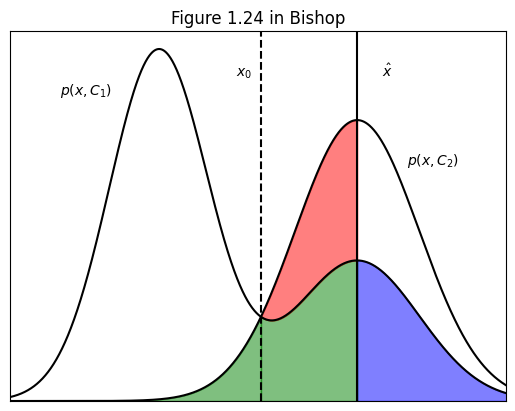

In [116]:
# Code to generate figure 1.24 from Bishop

from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


# C1 and C2 are both some classes which are mutually exclusive. E.g. Has Covid (C2) and does not have covid (C1). We randomly assign normal ditributions to both
# Data parameters
c1_mu = 3
c2_mu = 7
c1_sd = 1
c2_sd = 1.25
x = np.linspace(-5,15,50_000)

#Generating the gaussians
c1_y_data = norm.pdf(x, c1_mu, c1_sd)
c2_y_data = norm.pdf(x, c2_mu, c2_sd)
c1_botch_data = c2_y_data * 0.5 # I think there should be a better way to generate the C1 curve, but this works for now.
c1_total = c1_y_data + c1_botch_data

# Finding the intersection point of the two curves for x_0
diff_c1_c2 = c1_total - c2_y_data
sign_changes = np.where(np.diff(np.sign(diff_c1_c2)))[0]  # Indices where sign changes
x_intersection = x[sign_changes]

#Plotting the graph
plt.plot(x, c1_total, label='$p(x, C\_2$', color='black')
plt.plot(x, c2_y_data, color='black')
plt.axvline(c2_mu, color='black', label='$\hat{x}')
plt.axvline(x_intersection, color='black', linestyle='dashed', label='$x_0$')

# fill between areas
plt.fill_between(x, c1_total, where = x > c2_mu,  color='blue', alpha =0.5)
plt.fill_between(x, c1_total, where = ((x < c2_mu ) & (c1_total < c2_y_data)) , color='green', alpha=0.5)
plt.fill_between(x, c2_y_data, where = (x < x_intersection), color='green', alpha=0.5) # should be a way to combine this with the above
plt.fill_between(x, c1_total, c2_y_data, where = (x < c2_mu) & (x > x_intersection), color='red', alpha=0.5)

# Plot labels
# Find the y-coordinate of the peaks (for easier labelling)
c1_peak_y = norm.pdf(c1_mu, c1_mu, c1_sd)
c2_peak_y = norm.pdf(c2_mu, c2_mu, c2_sd)

plt.text(c1_mu - 2, c1_peak_y - 0.05, '$p(x, C_1)$', color='black')
plt.text(c2_mu + 1, c2_peak_y - 0.05, '$p(x, C_2)$', color='black')
plt.text(c2_mu + 0.5, c2_peak_y + 0.05, '$\hat{x}$', color='black')
plt.text(x_intersection - 0.5, c2_peak_y + 0.05, '$x_0$', color='black')

plt.xlim(left=0, right=10)
plt.ylim(bottom=0)
plt.yticks([])
plt.xticks([])

plt.title('Figure 1.24 in Bishop')

plt.show()